1. load sp500 stocks price data  
2. calculate different technical indicators and features for each stock  
3. aggregate on monthly level  
4. extract 150 most liquid stocks  
5. calculate returns for different time horizons and add them as features  
6. get factors for fama-french, calculate rolling factor betas  
7. fit a clustering model to group similar assets  
8. select assets based on cluster to form a portfolio using efficient frontier max sharpe ratio  
9. visualize portfolio returns and compare to sp500 (market to beat)  

In [2]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np
import datetime as dt
import pandas_ta
import warnings
warnings.filterwarnings('ignore')
#fetches historical data from yahoo finance
import yfinance as yf

<h2>Step 1: load price data</h2>

In [3]:
import requests
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
response = requests.get(url, headers=headers)
response.raise_for_status()
sp500 = pd.read_html(response.text)[0]
#sp500 = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0] 
#this doesnt work as agent is not specified and wiki rejects automated trafic
sp500.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [4]:
#get list of tickers to fetch from yahoo finance
sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')
symbols_list = sp500['Symbol'].unique().tolist()

In [5]:
#fetch stock data
end_date = '2025-05-31'
start_date = pd.to_datetime(end_date) - pd.DateOffset(365*12) #set start to 12 years ago

df = yf.download(tickers=symbols_list,
                start=start_date,
                end=end_date,
                auto_adjust=False)
df = df.stack()

[*********************100%***********************]  503 of 503 completed


In [6]:
df

Price               Adj Close       Close        High         Low        Open  \
Date       Ticker                                                               
2013-06-03 A        29.353945   32.553650   32.789700   32.217453   32.653790   
           AAPL     13.821265   16.097143   16.155714   15.802857   16.097500   
           ABBV     26.540491   43.360001   43.580002   42.750000   42.880001   
           ABT      29.367880   37.160000   37.180000   36.130001   36.630001   
           ACGL     16.320589   17.163334   17.183332   16.986668   17.090000   
...                       ...         ...         ...         ...         ...   
2025-05-30 XYZ      61.750000   61.750000   62.090000   60.884998   61.720001   
           YUM     143.244644  143.940002  144.479996  143.089996  144.039993   
           ZBH      91.931602   92.169998   93.040001   91.440002   92.940002   
           ZBRA    289.769989  289.769989  290.559998  283.920013  289.929993   
           ZTS     168.068008  168.630005  169.789993  165.339996  166.919998   

Price                   Volume  
Date       Ticker               
2013-06-03 A         5158201.0  
           AAPL    372352400.0  
           ABBV      7176800.0  
           ABT      10555000.0  
           ACGL      2365200.0  
...                        ...  
2025-05-30 XYZ      11486800.0  
           YUM       3184400.0  
           ZBH       3505200.0  
           ZBRA       656100.0  
           ZTS       5467800.0  

[1463989 rows x 6 columns]

In [7]:
df.columns = df.columns.str.lower()

<h2>Step 2: calculate technical indicators as features</h2>  
    <p style="margin-bottom: 0">* Garman-Klass Volatility (volatility)</p>
    <p style="margin-bottom: 0">* RSI (momentum of price change)  </p>
    <p style="margin-bottom: 0">* Bollinger Bands  (volatility)  </p>
    <p style="margin-bottom: 0">* ATR (volatility)  </p>
    <p style="margin-bottom: 0">* MACD  (momentum)  </p>
    <p style="margin-bottom: 0">* Dollar Volume (liquidity)</p>

In [8]:
df['garman_klass_vol'] = ((np.log(df['high'])-np.log(df['low']))**2)/2-(2*np.log(2)-1)*(np.log(df['adj close'])-np.log(df['open']))**2

In [9]:
df['rsi'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.rsi(close=x, length=20)) 
#groupby returns a pd Series of adj close of each stock in sp500
#transform applies a function to each pd series of adj close 
#pandas_ta.rsi returns the rsi value of each stock 

In [10]:
#break down
#A_adj_close, *_ = df.groupby(level=1)['adj close'] #unpacks and extract the first group(stock A) as A_adj_close
#pandas_ta.rsi(close=A_adj_close[1], length=20) #get rsi at different days for A

In [11]:
#since we are looking at rather long term movement and volatility of prices, we use logged prices
df['bbl']=df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log(x), length=20).iloc[:, 0])
df['bbm']=df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log(x), length=20).iloc[:, 1])
df['bbu']=df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.bbands(close=np.log(x), length=20).iloc[:, 2])

In [12]:
#atr = pd.Series()
#for i in df.groupby(level=1):
    #close = i[1]['adj close']
    #high = i[1]['high']
    #low = i[1]['low']
    #atr = pd.concat([atr, pandas_ta.atr(high, low, close, length=20)])
#df['atr'] = atr

In [13]:
def get_atr(timeseries_data):
    return pandas_ta.atr(timeseries_data['high'], timeseries_data['low'], timeseries_data['adj close'], length=20)

df['atr'] = df.groupby(level=1, group_keys=False).apply(get_atr)

In [14]:
df['macd'] = df.groupby(level=1)['adj close'].transform(lambda x: pandas_ta.macd(x).iloc[:, 0])

In [15]:
df['dollar_volume'] = df['adj close'] * df['volume'] / 1e6

<h2>Step 3: aggregate to monthly level</h2>

In [16]:
agg_cols = ['adj close', 'garman_klass_vol', 'rsi', 'bbl', 'bbm', 'bbu', 'atr', 'macd'] #use the last value of the month

data = df.unstack('Ticker')[agg_cols].resample('M').last().stack()
data['dollar_volume'] = df.unstack('Ticker')['dollar_volume'].resample('M').mean().stack().to_frame('dollar_volume') #average value of the month
data.dropna(inplace=True)

<h2>Step 4: extract top 150 most liquid stocks using 5-year rolling average of dollar volume as measurement for liquidity</h2>

In [17]:
data['dollar_volume'] = data.unstack('Ticker').loc[:, 'dollar_volume'].rolling(3*12).mean().stack() #look at liquidity of 3 year window
data['dollar_volume_rank'] = data.groupby(level=0)['dollar_volume'].rank(ascending=False)
data = data.loc[data['dollar_volume_rank']<150].drop(['dollar_volume', 'dollar_volume_rank'], axis=1)

In [18]:
data

Price               adj close  garman_klass_vol        rsi       bbl  \
Date       Ticker                                                      
2016-06-30 AAPL     21.824877         -0.002268  46.690271  3.048940   
           ABBV     41.974136         -0.057660  53.759209  3.676108   
           ABT      33.113186         -0.009054  53.364785  3.433127   
           ACN      97.668121         -0.007491  44.144458  4.553584   
           ADBE     95.790001          0.000096  49.729131  4.517520   
...                       ...               ...        ...       ...   
2025-05-31 WDAY    247.710007          0.000227  48.534163  5.449463   
           WFC      74.343254          0.000102  57.092526  4.267192   
           WMT      98.489967          0.000189  58.713286  4.556561   
           XOM     101.356842          0.000045  42.393083  4.601848   
           XYZ      61.750000          0.000192  56.735644  3.816319   

Price                   bbm       bbu        atr      macd  
Date       Ticker                                           
2016-06-30 AAPL    3.091936  3.134932   2.303375 -0.221785  
           ABBV    3.721640  3.767172  20.187572 -0.113116  
           ABT     3.472986  3.512845   6.408600 -0.122963  
           ACN     4.611856  4.670128  16.611000 -1.121386  
           ADBE    4.567947  4.618373   1.952725 -0.888056  
...                     ...       ...        ...       ...  
2025-05-31 WDAY    5.552131  5.654798   7.710600  0.615755  
           WFC     4.301423  4.335654   1.982170  1.104930  
           WMT     4.576307  4.596052   2.225520  0.962142  
           XOM     4.643997  4.686146   2.916019 -1.073388  
           XYZ     4.012837  4.209355   2.796141  1.696999  

[16092 rows x 8 columns]

<h2>Step 5: calculate monthly rate of returns for different time horizons as features</h2>

In [19]:
for lag in [1,2,3,6,9,12]:
    data[f'returns_{lag}m'] = data.groupby(level=1)['adj close'].transform(lambda x: x.pct_change(lag)
                                                                           .pipe(lambda y: y.clip(lower=y.quantile(0.05), upper=y.quantile(0.95)))
                                                                           .add(1)
                                                                           .pow(1/lag)
                                                                           .subtract(1))

In [20]:
# def calculate_returns(df):
#     lags = [1,2,3,6,9,12]
#     outlier_cutoff=0.005
#     for lag in lags:

#         df[f'returns_{lag}m'] = (df['adj close'].pct_change(lag)
#                                 .pipe(lambda x: x.clip(x.quantile(outlier_cutoff)))
#                                 .add(1)
#                                 .pow(1/lag)
#                                 .subtract(1))
#     return df

# data = data.groupby(level=1, group_keys=False).apply(calculate_returns)

In [21]:
data
#since we are using rolling windows for returns, the returns near the top are NaN

Price               adj close  garman_klass_vol        rsi       bbl  \
Date       Ticker                                                      
2016-06-30 AAPL     21.824877         -0.002268  46.690271  3.048940   
           ABBV     41.974136         -0.057660  53.759209  3.676108   
           ABT      33.113186         -0.009054  53.364785  3.433127   
           ACN      97.668121         -0.007491  44.144458  4.553584   
           ADBE     95.790001          0.000096  49.729131  4.517520   
...                       ...               ...        ...       ...   
2025-05-31 WDAY    247.710007          0.000227  48.534163  5.449463   
           WFC      74.343254          0.000102  57.092526  4.267192   
           WMT      98.489967          0.000189  58.713286  4.556561   
           XOM     101.356842          0.000045  42.393083  4.601848   
           XYZ      61.750000          0.000192  56.735644  3.816319   

Price                   bbm       bbu        atr      macd  returns_1m  \
Date       Ticker                                                        
2016-06-30 AAPL    3.091936  3.134932   2.303375 -0.221785         NaN   
           ABBV    3.721640  3.767172  20.187572 -0.113116         NaN   
           ABT     3.472986  3.512845   6.408600 -0.122963         NaN   
           ACN     4.611856  4.670128  16.611000 -1.121386         NaN   
           ADBE    4.567947  4.618373   1.952725 -0.888056         NaN   
...                     ...       ...        ...       ...         ...   
2025-05-31 WDAY    5.552131  5.654798   7.710600  0.615755    0.011061   
           WFC     4.301423  4.335654   1.982170  1.104930    0.058869   
           WMT     4.576307  4.596052   2.225520  0.962142    0.017570   
           XOM     4.643997  4.686146   2.916019 -1.073388   -0.022605   
           XYZ     4.012837  4.209355   2.796141  1.696999    0.056097   

Price              returns_2m  returns_3m  returns_6m  returns_9m  returns_12m  
Date       Ticker                                                               
2016-06-30 AAPL           NaN         NaN         NaN         NaN          NaN  
           ABBV           NaN         NaN         NaN         NaN          NaN  
           ABT            NaN         NaN         NaN         NaN          NaN  
           ACN            NaN         NaN         NaN         NaN          NaN  
           ADBE           NaN         NaN         NaN         NaN          NaN  
...                       ...         ...         ...         ...          ...  
2025-05-31 WDAY      0.029913   -0.020189   -0.001526   -0.006713     0.013277  
           WFC       0.023408   -0.013502   -0.001336    0.029559     0.020651  
           WMT       0.061706    0.002093    0.012148    0.028495     0.035317  
           XOM      -0.068285   -0.024827   -0.020514   -0.012807    -0.008481  
           XYZ       0.066102   -0.018460   -0.058310   -0.007502    -0.003082  

[16092 rows x 14 columns]

<h2>Step 6: add fama-french factors and calculate rolling factor betas as features</h2>

In [22]:
#fama french factors of the market measured monthly
ff_factor = pd.read_csv('famafrench_factor.csv')
ff_factor = ff_factor.loc[:743] #extract monthly data

In [23]:
#format the data
for col in ff_factor.columns:
    ff_factor[col] = ff_factor[col].astype('float')
    if col != 'Month':
        ff_factor[col] = ff_factor[col].div(100)
ff_factor['Month'] = ff_factor['Month'].astype('int')

def format_ff_date(date):
    month = int(date%100)
    year = int(date/100)
    day = 1
    date = pd.Timestamp(year=year, month=month, day=day)
    date = date + pd.offsets.MonthEnd(0)
    return date

ff_factor['Month'] = ff_factor['Month'].map(format_ff_date)
ff_factor.set_index('Month', drop=True, inplace=True)
ff_factor.index = ff_factor.index.rename('Date')

In [24]:
ff_factor

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-31,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027
1963-08-31,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025
1963-09-30,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027
1963-10-31,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029
1963-11-30,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027
...,...,...,...,...,...,...
2025-02-28,-0.0243,-0.0491,0.0491,0.0110,0.0306,0.0033
2025-03-31,-0.0639,-0.0149,0.0290,0.0211,-0.0047,0.0034
2025-04-30,-0.0084,-0.0186,-0.0340,-0.0285,-0.0267,0.0035


In [25]:
#calculate excess return using risk free rate from fama french factor
for lag in [1,2,3,6,9,12]:
    data[f'returns_{lag}m'] = data.groupby(level=1)[f'returns_{lag}m'].transform(lambda x: x - ff_factor.loc[x.index.get_level_values(0), 'RF'])

In [26]:
data

Price               adj close  garman_klass_vol        rsi       bbl  \
Date       Ticker                                                      
2016-06-30 AAPL     21.824877         -0.002268  46.690271  3.048940   
           ABBV     41.974136         -0.057660  53.759209  3.676108   
           ABT      33.113186         -0.009054  53.364785  3.433127   
           ACN      97.668121         -0.007491  44.144458  4.553584   
           ADBE     95.790001          0.000096  49.729131  4.517520   
...                       ...               ...        ...       ...   
2025-05-31 WDAY    247.710007          0.000227  48.534163  5.449463   
           WFC      74.343254          0.000102  57.092526  4.267192   
           WMT      98.489967          0.000189  58.713286  4.556561   
           XOM     101.356842          0.000045  42.393083  4.601848   
           XYZ      61.750000          0.000192  56.735644  3.816319   

Price                   bbm       bbu        atr      macd  returns_1m  \
Date       Ticker                                                        
2016-06-30 AAPL    3.091936  3.134932   2.303375 -0.221785         NaN   
           ABBV    3.721640  3.767172  20.187572 -0.113116         NaN   
           ABT     3.472986  3.512845   6.408600 -0.122963         NaN   
           ACN     4.611856  4.670128  16.611000 -1.121386         NaN   
           ADBE    4.567947  4.618373   1.952725 -0.888056         NaN   
...                     ...       ...        ...       ...         ...   
2025-05-31 WDAY    5.552131  5.654798   7.710600  0.615755    0.007261   
           WFC     4.301423  4.335654   1.982170  1.104930    0.055069   
           WMT     4.576307  4.596052   2.225520  0.962142    0.013770   
           XOM     4.643997  4.686146   2.916019 -1.073388   -0.026405   
           XYZ     4.012837  4.209355   2.796141  1.696999    0.052297   

Price              returns_2m  returns_3m  returns_6m  returns_9m  returns_12m  
Date       Ticker                                                               
2016-06-30 AAPL           NaN         NaN         NaN         NaN          NaN  
           ABBV           NaN         NaN         NaN         NaN          NaN  
           ABT            NaN         NaN         NaN         NaN          NaN  
           ACN            NaN         NaN         NaN         NaN          NaN  
           ADBE           NaN         NaN         NaN         NaN          NaN  
...                       ...         ...         ...         ...          ...  
2025-05-31 WDAY      0.026113   -0.023989   -0.005326   -0.010513     0.009477  
           WFC       0.019608   -0.017302   -0.005136    0.025759     0.016851  
           WMT       0.057906   -0.001707    0.008348    0.024695     0.031517  
           XOM      -0.072085   -0.028627   -0.024314   -0.016607    -0.012281  
           XYZ       0.062302   -0.022260   -0.062110   -0.011302    -0.006882  

[16092 rows x 14 columns]

In [27]:
#clean ff_factor preparing for rolling ols estimation for betas
risk_free_rate = ff_factor['RF'].copy()
ff_factor.drop(['RF'], axis=1, inplace=True)
ff_factor=ff_factor.join(data['returns_1m'])
ff_factor.dropna(inplace=True)

#filter out stocks with less than 10 months of data
size_observation = ff_factor.groupby(level=1).size()
valid_stocks = size_observation[size_observation>=10]
ff_factor = ff_factor[ff_factor.index.get_level_values('Ticker').isin(valid_stocks.index)]
ff_factor

Mkt-RF     SMB     HML     RMW     CMA  returns_1m
Date       Ticker                                                    
2016-07-31 AAPL    0.0394  0.0247 -0.0124  0.0131 -0.0116    0.089863
           ABBV    0.0394  0.0247 -0.0124  0.0131 -0.0116    0.078970
           ABT     0.0394  0.0247 -0.0124  0.0131 -0.0116    0.104711
           ACN     0.0394  0.0247 -0.0124  0.0131 -0.0116   -0.004437
           ADBE    0.0394  0.0247 -0.0124  0.0131 -0.0116    0.021410
...                   ...     ...     ...     ...     ...         ...
2025-05-31 WDAY    0.0606 -0.0072 -0.0288  0.0126  0.0251    0.007261
           WFC     0.0606 -0.0072 -0.0288  0.0126  0.0251    0.055069
           WMT     0.0606 -0.0072 -0.0288  0.0126  0.0251    0.013770
           XOM     0.0606 -0.0072 -0.0288  0.0126  0.0251   -0.026405
           XYZ     0.0606 -0.0072 -0.0288  0.0126  0.0251    0.052297

[15839 rows x 6 columns]

In [28]:
#get betas (sensitivity to factors)
betas = ff_factor.groupby('Ticker', group_keys=False).apply(lambda x: RollingOLS(endog=x['returns_1m'], exog=sm.add_constant(x.drop('returns_1m', axis=1)), window=min(24, x.shape[0]), min_nobs=6)
                                 .fit().params.drop('const', axis=1))

In [29]:
# def rollingRegression(df):
#     model = RollingOLS(endog=df['returns_1m'],
#                          exog=sm.add_constant(df.drop('returns_1m', axis=1)),
#                          window=min(24, df.shape[0]),
#                          min_nobs=len(df.columns)+1)
#     return model.fit().params.drop('const', axis=1)

# betas = ff_factor.groupby(level=1, group_keys=False).apply(rollingRegression)

In [30]:
#since the rolling ols model generates coefficients to estimate the next month and the model puts the row of coef in the last month, we need to shift it down
betas = betas.groupby(level=1).shift()
betas.dropna(inplace=True)
data = data.join(betas).dropna()
data.drop('adj close', axis=1, inplace=True)

In [31]:
data

garman_klass_vol        rsi       bbl       bbm       bbu  \
Date       Ticker                                                              
2018-07-31 AAPL           -0.001125  52.605227  3.779945  3.806667  3.833389   
           ABBV           -0.034887  45.920944  4.175801  4.230032  4.284263   
           ABT            -0.005484  62.882533  3.978713  4.026428  4.074144   
           ACN            -0.005027  42.887901  4.968127  4.998763  5.029399   
           ADBE            0.000267  45.877512  5.482274  5.534281  5.586288   
...                             ...        ...       ...       ...       ...   
2025-05-31 WDAY            0.000227  48.534163  5.449463  5.552131  5.654798   
           WFC             0.000102  57.092526  4.267192  4.301423  4.335654   
           WMT             0.000189  58.713286  4.556561  4.576307  4.596052   
           XOM             0.000045  42.393083  4.601848  4.643997  4.686146   
           XYZ             0.000192  56.735644  3.816319  4.012837  4.209355   

                         atr      macd  returns_1m  returns_2m  returns_3m  \
Date       Ticker                                                            
2018-07-31 AAPL     2.951554  0.267008    0.026383    0.007509    0.047878   
           ABBV    26.327959 -0.803123    0.004033   -0.031187   -0.013401   
           ABT      7.904626  0.873384    0.077833    0.032789    0.040761   
           ACN     17.945913 -0.013294   -0.027641    0.009860    0.016011   
           ADBE     5.835351  1.168924    0.001968   -0.010870    0.031977   
...                      ...       ...         ...         ...         ...   
2025-05-31 WDAY     7.710600  0.615755    0.007261    0.026113   -0.023989   
           WFC      1.982170  1.104930    0.055069    0.019608   -0.017302   
           WMT      2.225520  0.962142    0.013770    0.057906   -0.001707   
           XOM      2.916019 -1.073388   -0.026405   -0.072085   -0.028627   
           XYZ      2.796141  1.696999    0.052297    0.062302   -0.022260   

                   returns_6m  returns_9m  returns_12m    Mkt-RF       SMB  \
Date       Ticker                                                            
2018-07-31 AAPL      0.021309    0.012940     0.020460  0.606766  0.176186   
           ABBV     -0.029335    0.003895     0.024710  1.854413  0.561826   
           ABT       0.008827    0.021267     0.024237  1.521108  0.027776   
           ACN      -0.001563    0.011981     0.017835  0.846805 -0.155409   
           ADBE      0.032784    0.036237     0.042076  0.716838 -0.153933   
...                       ...         ...          ...       ...       ...   
2025-05-31 WDAY     -0.005326   -0.010513     0.009477  0.877432 -0.569544   
           WFC      -0.005136    0.025759     0.016851  0.847080 -0.163747   
           WMT       0.008348    0.024695     0.031517  0.646699  0.054714   
           XOM      -0.024314   -0.016607    -0.012281  0.460532 -0.291418   
           XYZ      -0.062110   -0.011302    -0.006882  1.961527  0.951887   

                        HML       RMW       CMA  
Date       Ticker                                
2018-07-31 AAPL   -0.010218  0.055218 -2.887324  
           ABBV    0.214286 -0.251720 -1.035481  
           ABT    -0.717803 -0.393251 -0.493517  
           ACN    -0.134369 -0.235120 -0.137258  
           ADBE   -0.248717 -1.195762 -2.582318  
...                     ...       ...       ...  
2025-05-31 WDAY   -0.336145 -1.435448 -0.129176  
           WFC     0.600179 -1.678369 -0.090671  
           WMT    -0.520560  0.381286  0.369217  
           XOM     1.033218  1.176384  0.057047  
           XYZ    -1.261673 -3.482726  2.128150  

[11163 rows x 18 columns]

<h2>Step 7: standardize all features, because we are going to use k-means (prevent domination of features with larger value)</h2>

In [32]:
standardized_data = data.copy()
for col in standardized_data.columns:
    standardized_data[col] = standardized_data.groupby(level=1)[col].transform(lambda x: (x-x.rolling(window=12).mean())/x.rolling(window=12).std())
standardized_data.dropna(inplace=True)

In [33]:
standardized_data

garman_klass_vol       rsi       bbl       bbm       bbu  \
Date       Ticker                                                             
2019-06-30 AAPL            0.697123  0.191462  0.090841  0.202015  0.319792   
           ABBV            1.680179 -0.572157 -1.857894 -1.480578 -0.714266   
           ABT             0.296824  0.503464  1.407288  1.652363  1.866636   
           ACN             0.740874  0.162115  1.411308  1.677613  1.843825   
           ADBE           -1.009276  0.450399  0.875581  1.527346  2.330653   
...                             ...       ...       ...       ...       ...   
2025-05-31 WDAY           -0.158419 -0.178854  0.163812  0.737185  1.136306   
           WFC             0.034087  0.044558  1.172684  0.961107  0.700669   
           WMT             0.263482 -0.158209  1.373221  1.105880  0.806380   
           XOM             0.650326 -0.904305 -1.029338 -1.330466 -1.476949   
           XYZ            -0.981484  0.817648 -1.645889 -1.244491 -0.719895   

                        atr      macd  returns_1m  returns_2m  returns_3m  \
Date       Ticker                                                           
2019-06-30 AAPL   -0.716350  0.517415    1.264488   -0.274855   -0.105736   
           ABBV   -1.471630 -0.982020   -0.605053   -0.663939   -0.702313   
           ABT     1.400239  1.292091    1.370202    0.167531   -0.356165   
           ACN     0.167832  0.365717    0.338183   -0.171609    0.163202   
           ADBE   -0.145030  1.026793    1.006540   -0.071355    0.592860   
...                     ...       ...         ...         ...         ...   
2025-05-31 WDAY    0.412347 -0.010991   -0.062250    0.490395   -0.551517   
           WFC    -1.437401  0.339555    0.473116    0.200088   -0.838574   
           WMT     0.699835 -0.014471   -0.368671    0.637381   -1.308685   
           XOM    -1.686929 -0.803289   -0.297179   -1.785835   -1.184660   
           XYZ    -0.022715  0.702621    0.392749    0.731793   -0.029676   

                   returns_6m  returns_9m  returns_12m    Mkt-RF       SMB  \
Date       Ticker                                                            
2019-06-30 AAPL      1.026409   -1.170442    -0.351271  0.126493  0.073624   
           ABBV     -0.772835   -0.849867    -0.834264 -0.973255 -1.241056   
           ABT       0.399268   -1.082752     1.156042 -0.880762  0.514967   
           ACN       2.172022    0.480640     0.069517  0.448495 -0.811662   
           ADBE      1.442647   -0.638556    -0.778967  0.345570 -0.830816   
...                       ...         ...          ...       ...       ...   
2025-05-31 WDAY      0.098656   -0.401618     1.677625  0.219572 -0.613996   
           WFC      -1.498056   -0.209727    -1.047706 -0.112984 -0.539347   
           WMT      -2.026336   -1.306295    -0.035317 -0.007916 -0.253630   
           XOM      -1.414601   -1.403557    -2.071502 -0.618305 -1.362768   
           XYZ      -1.282553   -0.741229    -0.314379 -0.932952  0.709890   

                        HML       RMW       CMA  
Date       Ticker                                
2019-06-30 AAPL   -0.791589  1.902017  0.493734  
           ABBV   -0.187549 -1.521676  1.677708  
           ABT     0.206634  1.294475  0.733406  
           ACN    -1.662294  0.725264  1.549261  
           ADBE    1.292046  0.492908 -0.406103  
...                     ...       ...       ...  
2025-05-31 WDAY    0.567052 -0.176403 -0.065585  
           WFC    -0.774361 -0.547420  0.351056  
           WMT    -1.889232 -2.295736  1.068642  
           XOM     2.327152  1.168976 -1.827643  
           XYZ    -2.261628 -0.370123  1.557294  

[9271 rows x 18 columns]

In [34]:
#this standardizes data using all 7 years of data
# standardized_data = data.copy()
# for col in standardized_data.columns:
#     standardized_data[col] = standardized_data.groupby(level=1)[col].transform(lambda x: (x-x.mean())/x.std())
# standardized_data.dropna(inplace=True)

<h2>Step 7.5 using pca to reduce dimensions</h2>

In [79]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(standardized_data)
explained_var = np.cumsum(pca.explained_variance_ratio_)
#choosing number of dimensions that is closes to explaining 90% of variance within the data
n_dim = min(range(len(explained_var)), key=lambda i: abs(explained_var[i]-0.9))

In [90]:
reduced_standardized_data = pd.DataFrame(PCA(n_components=8, random_state=0).fit(standardized_data).transform(standardized_data), index=standardized_data.index)

In [92]:
standardized_data = reduced_standardized_data

<h2>Step 8a: clustering using K-Means</h2>

In [93]:
#train(5years) test(1year) split
training_data = standardized_data.loc['2019-06-30': '2023-12-31']
test_data = standardized_data.loc['2024-01-31': '2025-05-31']

In [94]:
from sklearn.cluster import KMeans
kMeanModels = []
kmeans_training_clusters = pd.DataFrame()
kmeans_training_clusters.index = training_data.index
for k in range(2,7):
    kMeanModel = KMeans(n_clusters=k, random_state=0).fit(training_data)
    kMeanModels.append(kMeanModel)
    kmeans_training_clusters[f'cluster(k={k})'] = kMeanModel.labels_

In [95]:
kmeans_training_data = pd.concat([training_data, kmeans_training_clusters], axis=1)

In [96]:
kmeans_training_data

0         1         2         3         4         5  \
Date       Ticker                                                               
2019-06-30 AAPL   -0.215441  1.332639 -1.172448 -0.390739 -0.117950  1.241288   
           ABBV   -3.638648  0.697287  0.404794  1.359561  0.763085 -2.057674   
           ABT     2.366756 -0.325927 -1.392119 -0.832426  1.479829  1.255399   
           ACN     2.489245 -0.319132 -1.593193  1.521216  0.048808  0.417223   
           ADBE    1.992994 -0.167508  1.127344 -0.454486  0.392098  1.212146   
...                     ...       ...       ...       ...       ...       ...   
2023-12-31 WDAY    2.805637  0.368060 -0.789644  1.170473  0.031598 -1.021907   
           WFC     4.868289  1.575754 -2.019767 -0.707574 -0.436744 -1.713181   
           WMT    -1.769946  0.642802 -5.409100 -2.009466 -0.184950 -0.696723   
           XOM    -4.356179  1.038618 -2.567373 -2.524789  0.089251 -0.748940   
           XYZ     3.192022  2.080906  1.612976  1.470236 -0.698870 -0.251828   

                          6         7  cluster(k=2)  cluster(k=3)  \
Date       Ticker                                                   
2019-06-30 AAPL   -0.310328  0.478466             0             0   
           ABBV    1.074042  0.854031             0             0   
           ABT    -0.347120 -0.244248             1             1   
           ACN    -0.137443  0.752878             1             1   
           ADBE   -1.851632 -0.445433             1             1   
...                     ...       ...           ...           ...   
2023-12-31 WDAY   -2.211232 -0.447988             1             1   
           WFC    -0.080340  0.632252             1             1   
           WMT    -1.046914  0.131787             0             2   
           XOM    -0.181455 -0.141905             0             0   
           XYZ     0.029459 -0.470388             1             1   

                   cluster(k=4)  cluster(k=5)  cluster(k=6)  
Date       Ticker                                            
2019-06-30 AAPL               2             3             5  
           ABBV               3             0             3  
           ABT                1             1             1  
           ACN                1             1             1  
           ADBE               1             4             4  
...                         ...           ...           ...  
2023-12-31 WDAY               1             1             1  
           WFC                1             1             1  
           WMT                0             2             2  
           XOM                3             0             3  
           XYZ                1             4             4  

[7082 rows x 13 columns]

In [97]:
for k in range(2,7):
    print(kmeans_training_data[f'cluster(k={k})'].value_counts())

cluster(k=2)
1    3799
0    3283
Name: count, dtype: int64
cluster(k=3)
1    2836
0    2273
2    1973
Name: count, dtype: int64
cluster(k=4)
1    2256
0    1904
2    1497
3    1425
Name: count, dtype: int64
cluster(k=5)
2    1646
3    1481
1    1367
4    1341
0    1247
Name: count, dtype: int64
cluster(k=6)
1    1303
5    1302
4    1222
0    1222
3    1099
2     934
Name: count, dtype: int64


In [98]:
kmeans_training_data.columns

Index([             0,              1,              2,              3,
                    4,              5,              6,              7,
       'cluster(k=2)', 'cluster(k=3)', 'cluster(k=4)', 'cluster(k=5)',
       'cluster(k=6)'],
      dtype='object')

In [99]:
training_data = kmeans_training_data

<h2>Step 9: form portfolios(assign weights) with clusters using max sharpe ratio</h2>

In [100]:
def seperating_clusters(df, n_clusters_min, n_clusters_max):
    components_dict = {}
    for k in range(n_clusters_min,n_clusters_max+1):
        components = list(np.zeros(k))
        for i in range(k):
            components[i] = df[df[f'cluster(k={k})']==i].index.to_frame().set_index('Date').groupby('Date').apply(lambda x: x['Ticker'].to_list())
        components_dict[f'k={k}'] = components
    return components_dict

In [101]:
components_dict = seperating_clusters(training_data, 2,6) #{k: [tickers for cluster0, ...]}

In [102]:
start_date = components_dict['k=2'][0].index[0].strftime('%Y-%m-%d')
end_date = components_dict['k=2'][0].index[-1].strftime('%Y-%m-%d')

adjclose_df = yf.download(tickers=standardized_data.index.get_level_values(1).unique().to_list(),
                start=start_date,
                end=end_date,
                auto_adjust=False)['Adj Close']

[*********************100%***********************]  164 of 164 completed


In [103]:
adjclose_df

Ticker,AAPL,ABBV,ABT,ACN,ADBE,ADI,ADP,ADSK,AIG,ALGN,...,VLO,VRTX,VZ,WDAY,WDC,WFC,WMT,WYNN,XOM,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2019-07-01,48.347607,55.961845,75.744827,170.456223,300.970001,102.613831,146.608963,169.289993,46.028671,271.679993,...,65.056587,181.839996,40.080566,213.470001,36.317860,40.232758,33.637115,124.519394,57.046547,73.199997
2019-07-02,48.630657,56.594669,76.157227,172.034317,301.390015,101.284309,142.705643,170.100006,45.985931,270.899994,...,62.315331,179.529999,41.120422,213.960007,35.352310,39.844685,33.935112,126.151176,56.420662,73.970001
2019-07-03,49.033661,57.151222,76.775818,174.196075,305.700012,100.980927,144.582413,172.000000,46.875042,275.000000,...,63.303745,183.259995,41.120422,216.800003,35.067036,40.207455,34.154053,126.540161,56.957153,74.260002
2019-07-05,48.990475,55.649277,76.578568,174.579193,303.980011,100.704315,145.243210,172.229996,46.686966,273.290009,...,63.195629,178.339996,41.247753,216.009995,35.491295,40.300255,34.050667,125.999390,56.726154,74.309998
2019-07-08,47.980591,54.299770,76.282745,173.594070,302.920013,99.785248,144.564774,169.869995,46.986176,272.239990,...,62.824989,176.750000,40.950645,215.270004,36.478786,40.097778,34.275684,126.236565,56.986946,73.430000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22,191.974686,145.467117,105.375404,343.931854,598.750000,191.341293,223.692429,242.759995,64.871460,271.869995,...,125.326836,405.250000,33.449142,272.570007,39.683254,47.141121,51.213169,88.760948,95.891006,77.139999
2023-12-26,191.429306,145.166672,105.568718,342.942078,598.260010,193.059555,225.212967,245.070007,65.065308,274.190002,...,126.265396,407.660004,33.440212,273.970001,39.758610,47.582050,51.134705,89.330307,96.107422,78.180000
2023-12-27,191.528458,145.410797,106.109940,343.320496,596.080017,193.525543,224.312271,245.110001,65.084694,275.279999,...,124.966614,408.049988,33.288551,273.700012,39.502396,47.284904,51.615288,88.967087,95.655769,79.599998


In [104]:
from pypfopt import expected_returns
from pypfopt import risk_models
from pypfopt.efficient_frontier.efficient_frontier import EfficientFrontier

In [105]:
#take pd series of list of tickers as parameter and returns a list of dictionary of ticker:weight
def max_sharpe_weights(tickers):
    w = []
    for i, l in tickers.items():
        price_df = adjclose_df.loc[:, l]
        
        returns = expected_returns.mean_historical_return(price_df, frequency=252) #get annual return given price of assets
        
        cov = risk_models.sample_cov(price_df, frequency=252) #covariances between i-th and j-th asset's annual returns
        
        ef = EfficientFrontier(expected_returns=returns, cov_matrix=cov, weight_bounds=(1/(2*len(price_df.columns)),0.1), solver='SCS')
        try:
            ef.max_sharpe()
            w.append(dict(ef.clean_weights()))
        except Exception as e:
            w.append({key: 1/len(l) for key in l})
    return w

In [106]:
#takes pd dataframe of portfolio for a month and returns pd dataframe of weighted daily return rate
def portDailyReturn(port):
    start_date = port.name.strftime('%Y-%m-%d')
    end_date = (port.name + pd.DateOffset(months=1)).strftime('%Y-%m-%d')
    tickers = port.iloc[0, 0] #list of tickers
    weights = port.iloc[0,1] #dict of weights
    returns_df = (adjclose_df.loc[start_date:end_date, tickers]).pct_change()
    
    for key, item in weights.items():
        returns_df[key] = returns_df[key] * item
    return returns_df.sum(axis=1).to_frame('return')


In [107]:
#takes pd dataframe of daily return rate and returns pd series of daily time weighted returns
def get_TWR(return_df):
    prev=0
    TWR = []
    for i in range(len(return_df)):
        prev = float((1+prev)*(1+return_df.iloc[i])-1)
        TWR.append(float(prev))
    return pd.Series(TWR, index=return_df.index)

In [109]:
#get TWR and daily returns for each portfolio
TWR_dict = {}
for key, components in components_dict.items():
    k = int(key[2])
    portTWRs = [None] * k
    portReturns = [None] * k
    for i, component in enumerate(components):
        component=component.to_frame('Tickers')
        component['weights'] = max_sharpe_weights(component['Tickers'])
        temp_returns_df = component.groupby('Date').apply(portDailyReturn).pipe(lambda x: x.set_index(x.index.get_level_values(1)))
        portReturns[i] = temp_returns_df
        TWR = get_TWR(temp_returns_df)
        portTWRs[i] = TWR
    TWR_dict[f'k={k}'] = portTWRs

In [110]:
TWR_dict

{'k=2': [Date
  2019-07-01    0.000000
  2019-07-02   -0.004289
  2019-07-03    0.006780
  2019-07-05    0.000075
  2019-07-08   -0.007820
                  ...   
  2023-12-22    1.594872
  2023-12-26    1.604073
  2023-12-27    1.610651
  2023-12-28    1.608385
  2023-12-29    1.601843
  Length: 1150, dtype: float64,
  Date
  2019-07-01    0.000000
  2019-07-02    0.002759
  2019-07-03    0.009582
  2019-07-05    0.007981
  2019-07-08    0.006337
                  ...   
  2023-12-22    1.717994
  2023-12-26    1.734964
  2023-12-27    1.755449
  2023-12-28    1.747980
  2023-12-29    1.738466
  Length: 1150, dtype: float64],
 'k=3': [Date
  2019-07-01    0.000000
  2019-07-02   -0.005940
  2019-07-03    0.005886
  2019-07-05   -0.001790
  2019-07-08   -0.010125
                  ...   
  2023-12-22    1.650857
  2023-12-26    1.665522
  2023-12-27    1.673408
  2023-12-28    1.673375
  2023-12-29    1.664256
  Length: 1150, dtype: float64,
  Date
  2019-07-01    0.000000
  2019-07-0

Compare portfolios' return with S&P500 ETS's return

In [111]:
spy_adjclose = yf.download(tickers='SPY', start='2017-08-01', end='2024-01-01', auto_adjust=False)['Adj Close']
spy_returns = spy_adjclose.pct_change()
spy_returns.iloc[0,0] = 0
spy_returns = get_TWR(spy_returns)
#portTWRs.append(spy_returns)

[*********************100%***********************]  1 of 1 completed


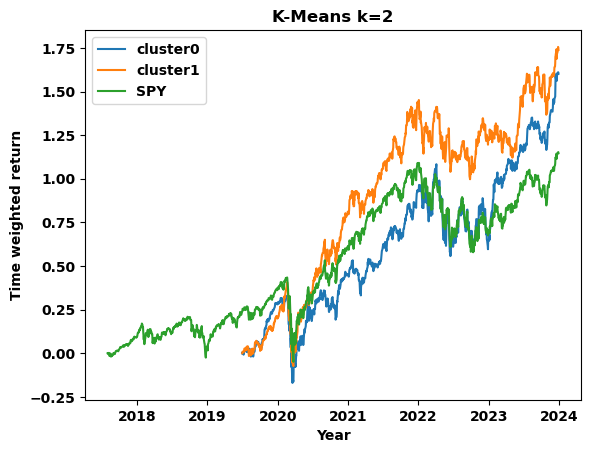

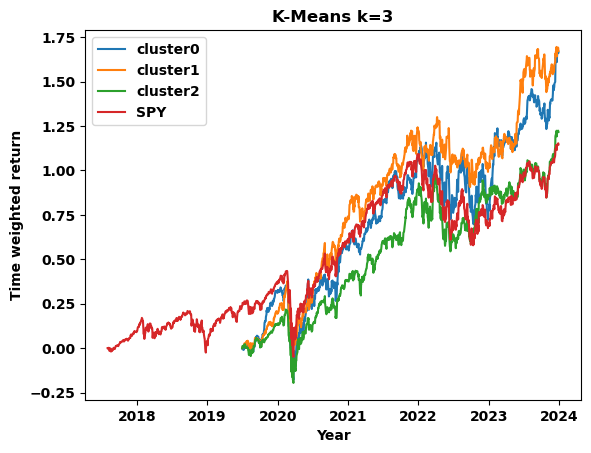

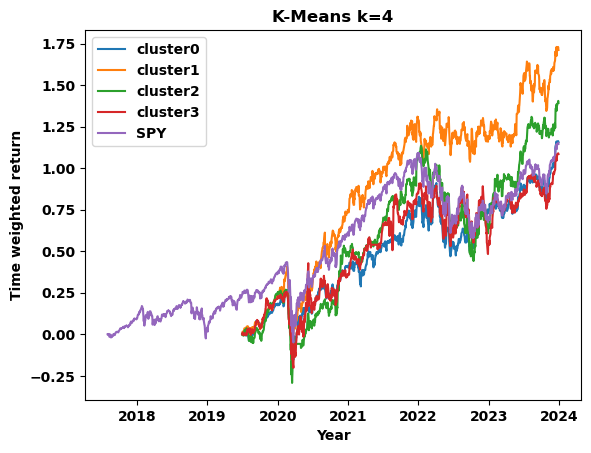

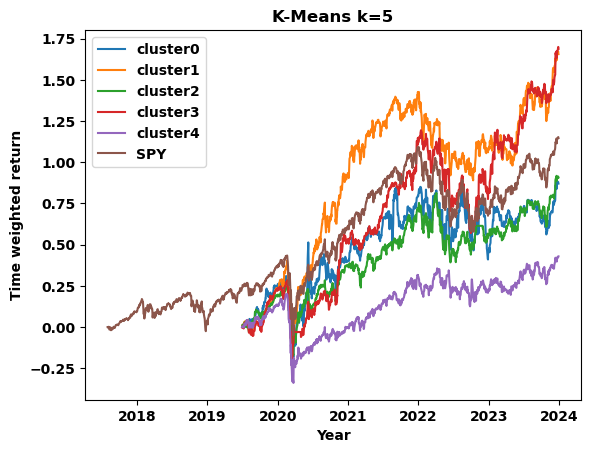

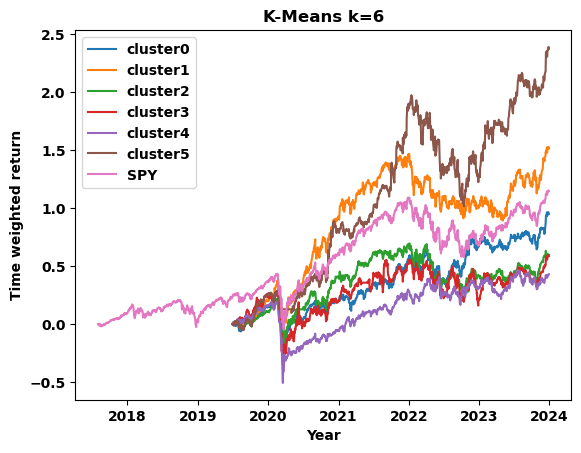

In [113]:
#visualize comparisons
for key, portTWRs in TWR_dict.items():
    k = int(key[2])
    for cluster, component in enumerate(portTWRs):
        plt.plot(component, label=f'cluster{cluster}')
    plt.plot(spy_returns, label='SPY')
    plt.title(f'K-Means k={k}')
    plt.legend()
    plt.xlabel('Year')
    plt.ylabel('Time weighted return')
    plt.show()

<span style="color: red">TODO: add elbow method and find the best kmeans model</span>

<h2>Step 10: apply data to data later to test its performance</h2>

In [114]:
test_data

0         1         2         3         4         5  \
Date       Ticker                                                               
2024-01-31 AAPL   -0.850199 -2.470780  3.163958  1.490825 -0.709310 -0.552751   
           ABBV    4.159059  1.124212 -0.316159 -0.711672  0.396528 -2.298736   
           ABT     2.745716  0.706390  0.283868  1.673827 -0.557660 -0.803082   
           ACN     3.622489 -0.036504  0.989067 -0.540732  0.015354 -2.000134   
           ADBE    1.014085 -1.226656 -0.064100  0.139663 -1.305509  2.889214   
...                     ...       ...       ...       ...       ...       ...   
2025-05-31 WDAY    0.889378 -0.862585  0.551900  0.185120 -0.040190  0.185056   
           WFC    -0.514542  0.012786 -0.142893  0.817856  0.515063 -0.368598   
           WMT    -0.452442 -1.240089 -0.813202  2.461499  2.298679 -0.638403   
           XOM    -4.736952 -0.342269  2.335316 -2.327979 -0.419321  0.476454   
           XYZ    -1.824673  2.664319 -1.828733  0.913592  1.659548 -0.537380   

                          6         7  
Date       Ticker                      
2024-01-31 AAPL   -1.895391 -1.670960  
           ABBV   -0.975963  0.654909  
           ABT    -1.350199  0.570834  
           ACN    -1.032207 -1.033211  
           ADBE    0.463739  0.161317  
...                     ...       ...  
2025-05-31 WDAY    0.297005 -0.889972  
           WFC    -1.919868  0.302782  
           WMT    -1.052536 -0.258368  
           XOM    -0.241254  0.278853  
           XYZ     0.027970 -1.973211  

[2189 rows x 8 columns]

In [115]:
#test_data['cluster'] = kMeanModel.predict(test_data)
test_clusters = pd.DataFrame()
test_clusters.index = test_data.index
for i, k in enumerate(range(2,7)):
    test_clusters[f'cluster(k={k})'] = kMeanModels[i].predict(test_data)
test_data = pd.concat([test_data, test_clusters], axis=1)

In [116]:
test_data

0         1         2         3         4         5  \
Date       Ticker                                                               
2024-01-31 AAPL   -0.850199 -2.470780  3.163958  1.490825 -0.709310 -0.552751   
           ABBV    4.159059  1.124212 -0.316159 -0.711672  0.396528 -2.298736   
           ABT     2.745716  0.706390  0.283868  1.673827 -0.557660 -0.803082   
           ACN     3.622489 -0.036504  0.989067 -0.540732  0.015354 -2.000134   
           ADBE    1.014085 -1.226656 -0.064100  0.139663 -1.305509  2.889214   
...                     ...       ...       ...       ...       ...       ...   
2025-05-31 WDAY    0.889378 -0.862585  0.551900  0.185120 -0.040190  0.185056   
           WFC    -0.514542  0.012786 -0.142893  0.817856  0.515063 -0.368598   
           WMT    -0.452442 -1.240089 -0.813202  2.461499  2.298679 -0.638403   
           XOM    -4.736952 -0.342269  2.335316 -2.327979 -0.419321  0.476454   
           XYZ    -1.824673  2.664319 -1.828733  0.913592  1.659548 -0.537380   

                          6         7  cluster(k=2)  cluster(k=3)  \
Date       Ticker                                                   
2024-01-31 AAPL   -1.895391 -1.670960             0             2   
           ABBV   -0.975963  0.654909             1             1   
           ABT    -1.350199  0.570834             1             1   
           ACN    -1.032207 -1.033211             1             1   
           ADBE    0.463739  0.161317             1             2   
...                     ...       ...           ...           ...   
2025-05-31 WDAY    0.297005 -0.889972             1             2   
           WFC    -1.919868  0.302782             0             2   
           WMT    -1.052536 -0.258368             0             2   
           XOM    -0.241254  0.278853             0             0   
           XYZ     0.027970 -1.973211             0             0   

                   cluster(k=4)  cluster(k=5)  cluster(k=6)  
Date       Ticker                                            
2024-01-31 AAPL               0             2             0  
           ABBV               1             1             4  
           ABT                1             1             1  
           ACN                1             4             4  
           ADBE               0             2             0  
...                         ...           ...           ...  
2025-05-31 WDAY               0             4             0  
           WFC                0             2             2  
           WMT                0             2             2  
           XOM                3             0             3  
           XYZ                2             3             5  

[2189 rows x 13 columns]

In [117]:
test_data.index.get_level_values(0)

DatetimeIndex(['2024-01-31', '2024-01-31', '2024-01-31', '2024-01-31',
               '2024-01-31', '2024-01-31', '2024-01-31', '2024-01-31',
               '2024-01-31', '2024-01-31',
               ...
               '2025-05-31', '2025-05-31', '2025-05-31', '2025-05-31',
               '2025-05-31', '2025-05-31', '2025-05-31', '2025-05-31',
               '2025-05-31', '2025-05-31'],
              dtype='datetime64[ns]', name='Date', length=2189, freq=None)

In [118]:
#get portfolio components for each cluster and month
#components = seperating_clusters(test_data, 4)
test_data.index.set_levels(test_data.index.levels[0] + pd.offsets.DateOffset(day=1), level=0)
test_components_dict = seperating_clusters(test_data, 2,6) #{k: [tickers for cluster0, ...]}

# #reindex date to beginning of next month
# for component in components:
#      component.index = component.index + pd.offsets.DateOffset(day=1)

start_date = test_components_dict['k=2'][0].index[0].strftime('%Y-%m-%d')
end_date = test_components_dict['k=2'][0].index[-1].strftime('%Y-%m-%d')

adjclose_df = yf.download(tickers=standardized_data.index.get_level_values(1).unique().to_list(),
                start=start_date,
                end=end_date,
                auto_adjust=False)['Adj Close']

#get TWR and daily returns for each portfolio
test_TWR_dict = {}
for key, components in test_components_dict.items():
    k = int(key[2])
    test_portTWRs = [None] * k
    test_portReturns = [None]*k
    for i, component in enumerate(components):
        component=component.to_frame('Tickers')
        component['weights'] = max_sharpe_weights(component['Tickers'])
        temp_returns_df = component.groupby('Date').apply(portDailyReturn).pipe(lambda x: x.set_index(x.index.get_level_values(1)))
        test_portReturns[i] = temp_returns_df
        TWR = get_TWR(temp_returns_df)
        test_portTWRs[i] = TWR
    test_TWR_dict[f'k={k}'] = test_portTWRs

[*********************100%***********************]  164 of 164 completed


In [119]:
test_TWR_dict

{'k=2': [Date
  2024-01-31    0.000000
  2024-02-01    0.013951
  2024-02-02    0.006523
  2024-02-05   -0.009694
  2024-02-06    0.000552
                  ...   
  2025-05-23    0.635181
  2025-05-27    0.666729
  2025-05-28    0.656996
  2025-05-29    0.665060
  2025-05-30    0.668280
  Length: 340, dtype: float64,
  Date
  2024-01-31    0.000000
  2024-02-01    0.012100
  2024-02-02    0.013769
  2024-02-05    0.011270
  2024-02-06    0.010545
                  ...   
  2025-05-23    0.417619
  2025-05-27    0.430558
  2025-05-28    0.424593
  2025-05-29    0.423135
  2025-05-30    0.436968
  Length: 340, dtype: float64],
 'k=3': [Date
  2024-01-31    0.000000
  2024-02-01    0.012096
  2024-02-02    0.006824
  2024-02-05   -0.008431
  2024-02-06    0.001793
                  ...   
  2025-05-23    0.341670
  2025-05-27    0.372138
  2025-05-28    0.365211
  2025-05-29    0.378590
  2025-05-30    0.376976
  Length: 340, dtype: float64,
  Date
  2024-01-31    0.000000
  2024-02-01  

In [120]:
spy_adjclose = yf.download(tickers='SPY', start='2024-01-02', end='2025-05-30', auto_adjust=False)['Adj Close']
spy_returns = spy_adjclose.pct_change()
spy_returns.iloc[0,0] = 0
spy_returns = get_TWR(spy_returns)
test_portTWRs.append(spy_returns)

[*********************100%***********************]  1 of 1 completed


In [121]:
daily_rf_return = test_TWR_dict['k=2'][0].groupby('Date').transform(lambda x: (1+risk_free_rate.loc[x.name.to_period('M').to_timestamp()+ pd.offsets.DateOffset(months=1) - pd.offsets.DateOffset(days=1)])**(1/365)-1).to_frame('return')
daily_rf_return = get_TWR(daily_rf_return)

In [122]:
ticks = []
for i in np.linspace(0, len(test_TWR_dict['k=2'][0])-1, 5):
    i = int(i)
    ticks.append(test_TWR_dict['k=2'][0].index[i])

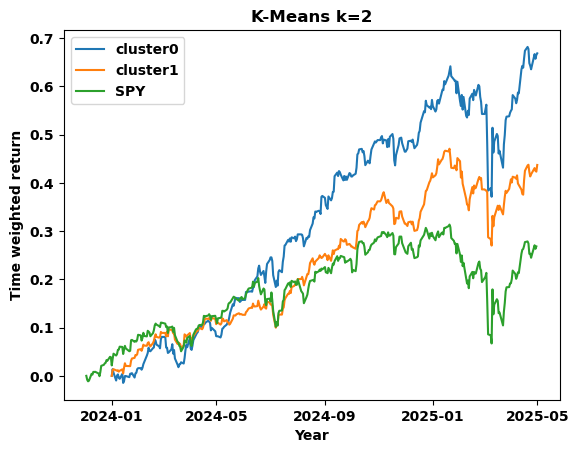

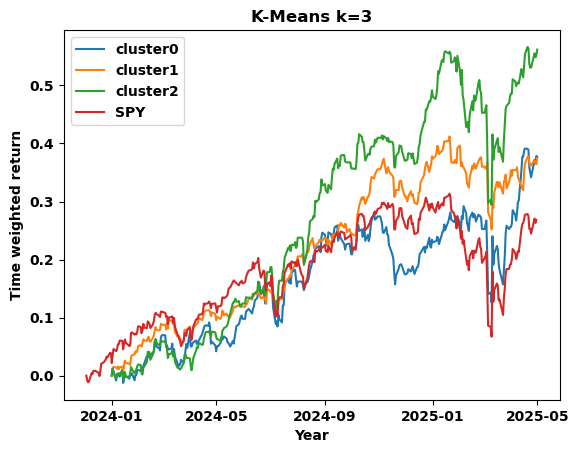

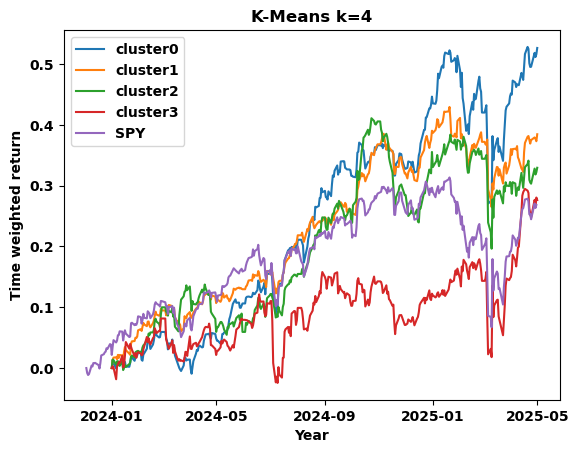

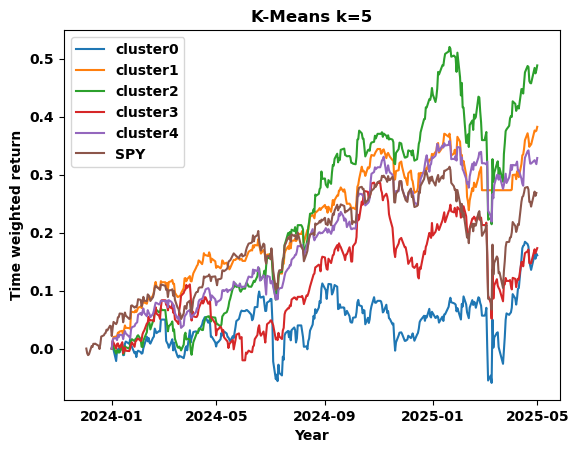

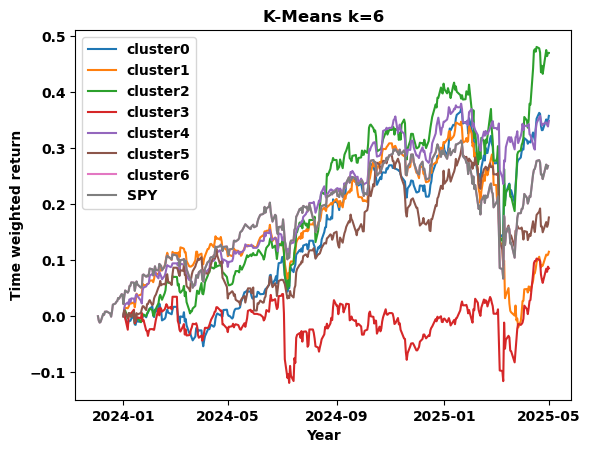

In [123]:
#visualize comparisons
for key, portTWRs in test_TWR_dict.items():
    k = int(key[2])
    for cluster, component in enumerate(portTWRs):
        plt.plot(component, label=f'cluster{cluster}')
    plt.plot(spy_returns, label='SPY')
    plt.title(f'K-Means k={k}')
    plt.legend()
    plt.xlabel('Year')
    plt.ylabel('Time weighted return')
    plt.xticks(ticks=ticks, labels=[tick.to_period('M') for tick in ticks])
    plt.show()

Conclusion: since most the clustered portfolios and follow the shape of the market(SPY), I believe that the clustering has little use in selecting securities that avoid risks in the market and the edge that most clustered portfolios gained over SPY is due to the max sharpe raio process.